# Over-Refusal in the Life Sciences: Analysis

This notebook ties the pipeline together in three stages:

1. **Collect responses** (live, needs your `ANTHROPIC_API_KEY`) — run the query set through the two Claude models.
2. **Score responses** (live, needs your `OPENAI_API_KEY`) — label each response with the non-Claude judge.
3. **Analyze** (no key needed) — compute tables and figures from the scored data.

Stages 1 and 2 are OFF by default. You can run the entire analysis stage on **synthetic data** first, with zero API keys, to confirm the tables and figures work. Set `USE_SYNTHETIC = False` once you have a real `results/scored_responses.csv` from a pilot run.

Keys live only in your local `.env` file; they are never needed to build or test this notebook.


## Setup


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np
import pandas as pd
import analysis_utils as au

DATA = '../data/queries.csv'
RESPONSES = '../results/model_responses.csv'
SCORED = '../results/scored_responses.csv'
pd.set_option('display.width', 140)
print('Queries in dataset:', len(pd.read_csv(DATA)))

Queries in dataset: 93


## Stage 1 — Collect responses (LIVE, uses your Anthropic key)

Runs a small pilot sample through the two active Claude models. Set `RUN_MODELS = True` to actually call the API.


In [2]:
RUN_MODELS = False   # set True to collect responses (uses ANTHROPIC_API_KEY)
PILOT_N = 15         # number of queries to sample for the pilot

if RUN_MODELS:
    import run_models
    responses = run_models.run_all(queries_path=DATA, pilot_n=PILOT_N, out_path=RESPONSES)
    print(responses.shape)
    display(responses.head())
else:
    print('Skipped. Set RUN_MODELS=True to collect responses.')

Skipped. Set RUN_MODELS=True to collect responses.


## Stage 2 — Score responses (LIVE, uses your OpenAI key)

Labels each collected response with the non-Claude judge (refusal / useful / not_useful, plus the caution-driven vs. other tag). Set `RUN_JUDGE = True` to run it.


In [3]:
RUN_JUDGE = False   # set True to score responses (uses OPENAI_API_KEY / JUDGE_MODEL)

if RUN_JUDGE:
    import judge
    scored_live = judge.score_all(RESPONSES, SCORED)
    print(scored_live.shape)
    display(scored_live.head())
else:
    print('Skipped. Set RUN_JUDGE=True to score responses.')

Skipped. Set RUN_JUDGE=True to score responses.


## Stage 3 — Analyze

Load the scored data (synthetic by default), then attach `topic` and `is_control` from the query metadata so the by-topic and control comparisons work.


In [4]:
USE_SYNTHETIC = True   # set False to use the real results/scored_responses.csv

def synthetic_scored(queries_path=DATA, models=('claude-sonnet-5','claude-opus-4.8'), seed=7):
    """Illustrative scored data with no API calls. Opus refuses more; Sonnet has more 'other' failures."""
    rng = np.random.default_rng(seed)
    q = pd.read_csv(queries_path)
    profile = {
        'claude-sonnet-5': dict(refusal=.06, nu_caution=.10, nu_other=.14),
        'claude-opus-4.8': dict(refusal=.14, nu_caution=.13, nu_other=.05),
    }
    rows = []
    for m in models:
        p = profile.get(m, dict(refusal=.1, nu_caution=.1, nu_other=.1))
        for _, row in q.iterrows():
            r = rng.random()
            if r < p['refusal']:
                label, cause = 'refusal', None
            elif r < p['refusal'] + p['nu_caution']:
                label, cause = 'not_useful', 'caution_driven'
            elif r < p['refusal'] + p['nu_caution'] + p['nu_other']:
                label, cause = 'not_useful', 'other'
            else:
                label, cause = 'useful', None
            rows.append(dict(query_id=row.query_id, model_name=m, label=label,
                             cause_tag=cause, justification='synthetic'))
    return pd.DataFrame(rows)

if USE_SYNTHETIC:
    scored = synthetic_scored()
    print('Using SYNTHETIC data (no keys). Set USE_SYNTHETIC=False for real results.')
else:
    scored = pd.read_csv(SCORED)
    print('Loaded real scored data:', SCORED)

meta = pd.read_csv(DATA)[['query_id', 'topic', 'is_control']]
scored = scored.merge(meta, on='query_id', how='left')
scored.head()

Using SYNTHETIC data (no keys). Set USE_SYNTHETIC=False for real results.


,query_id,model_name,label,cause_tag,justification,topic,is_control
0,ID001,claude-sonnet-5,useful,NaN,synthetic,infectious_disease_diagnostics,False
1,ID002,claude-sonnet-5,useful,NaN,synthetic,infectious_disease_diagnostics,False
2,ID003,claude-sonnet-5,useful,NaN,synthetic,infectious_disease_diagnostics,False
3,ID004,claude-sonnet-5,not_useful,other,synthetic,infectious_disease_diagnostics,False
4,ID005,claude-sonnet-5,useful,NaN,synthetic,infectious_disease_diagnostics,False


### Headline numbers by model

False-refusal, useful, not-useful, and combined unhelpful rates, plus the caution-driven share of not-useful answers.


In [5]:
au.summary_by_model(scored)

,model_name,n,false_refusal_rate,useful_rate,not_useful_rate,unhelpful_rate,caution_driven_share
0,claude-opus-4.8,93,0.129032,0.763441,0.107527,0.236559,0.800000
1,claude-sonnet-5,93,0.075269,0.698925,0.225806,0.301075,0.333333


### Usefulness decomposition (caution vs capability)

Four segments that sum to 1 per model, plus the roll-ups. `over_caution_cost` = refusal + caution-driven; `capability_cost` = other. This is the table that answers whether a model's shortfall is over-caution or capability.


In [6]:
dec = au.decomposition_by_model(scored)
dec

,model_name,n,useful,refusal,not_useful_caution,not_useful_other,over_caution_cost,capability_cost
0,claude-opus-4.8,93,0.763441,0.129032,0.086022,0.021505,0.215054,0.021505
1,claude-sonnet-5,93,0.698925,0.075269,0.075269,0.150538,0.150538,0.150538


### Life-science vs control (is over-caution bio-specific?)

Headline metric is `over_caution_rate` (refusal + caution-driven), which isolates safety misfires. `other_not_useful_rate` is carried alongside only as a check: if it is roughly flat across the two sets, the over-caution gap is cleanly attributable to biological content.


In [7]:
au.lifescience_vs_control(scored)

,model_name,set,over_caution_rate,other_not_useful_rate,n
0,claude-opus-4.8,control,0.217391,0.043478,23
1,claude-opus-4.8,life_science,0.214286,0.014286,70
2,claude-sonnet-5,control,0.130435,0.130435,23
3,claude-sonnet-5,life_science,0.157143,0.157143,70


### By topic


In [8]:
by_topic = (au.false_refusal_rate(scored, group_cols=('model_name','topic'))
            .merge(au.not_useful_rate(scored, group_cols=('model_name','topic')),
                   on=['model_name','topic'])
            .merge(au.over_caution_rate(scored, group_cols=('model_name','topic')),
                   on=['model_name','topic']))
by_topic.sort_values(['model_name','over_caution_rate'], ascending=[True, False])

,model_name,topic,refusal_rate,not_useful_rate,over_caution_rate
6,claude-opus-4.8,molecular_biology_genetics,0.150000,0.150000,0.300000
2,claude-opus-4.8,control_radiological_nuclear,0.142857,0.142857,0.285714
5,claude-opus-4.8,lab_biosafety,0.066667,0.200000,0.266667
1,claude-opus-4.8,control_cyber,0.250000,0.000000,0.250000
4,claude-opus-4.8,infectious_disease_diagnostics,0.150000,0.050000,0.200000
0,claude-opus-4.8,control_chemistry,0.125000,0.125000,0.125000
3,claude-opus-4.8,drug_discovery_pharmacology,0.066667,0.066667,0.066667
13,claude-sonnet-5,molecular_biology_genetics,0.200000,0.300000,0.250000
12,claude-sonnet-5,lab_biosafety,0.000000,0.333333,0.200000
9,claude-sonnet-5,control_radiological_nuclear,0.000000,0.428571,0.142857


### Judge vs expert agreement (Cohen's kappa)

This is the number to report with confidence. You do **not** need to label every response: run `python src/select_validation_subset.py` to flag a recommended subset (it fills a `priority` column in `results/expert_labels.csv` with the refusals, the truncated responses, and a stratified sample), hand-label those rows, and leave the rest blank.

`au.judge_expert_agreement_from_sheets(scored, expert)` is blank-safe: it keeps only the rows you labeled, joins them to the judge's labels on `(query_id, model_name)`, and returns kappa, percent agreement, `n`, and the confusion matrix. The cell below runs it on placeholder labels so you can see the output shape.

In [ ]:
# --- Real usage (after hand-labeling) ---
# Blank-safe: keeps only the rows you actually labeled, joins them to the judge's
# labels on (query_id, model_name), and reports kappa + agreement + confusion matrix.
# Label the priority subset (src/select_validation_subset.py); leave the rest blank.
# el = pd.read_csv('../results/expert_labels.csv')
# res = au.judge_expert_agreement_from_sheets(scored, el)
# print({k: res[k] for k in ('cohen_kappa', 'percent_agreement', 'n')})
# print('labels:', res['labels'])
# print('confusion (rows=expert, cols=judge):', res['confusion_matrix'])
# if 'note' in res: print('NOTE:', res['note'])

# --- Placeholder demonstration (synthetic labels with a few disagreements) ---
demo = scored.sample(25, random_state=1).reset_index(drop=True).copy()
rng = np.random.default_rng(0)
demo['expert_label'] = demo['label']
flip = rng.choice(len(demo), size=4, replace=False)
labs = ['useful', 'not_useful', 'refusal']
demo.loc[flip, 'expert_label'] = [rng.choice(labs) for _ in flip]
print(au.judge_expert_agreement_from_sheets(scored, demo))

### Figures


Matplotlib is building the font cache; this may take a moment.


saved: ../results/figures/rates_by_model.png ../results/figures/usefulness_decomposition.png


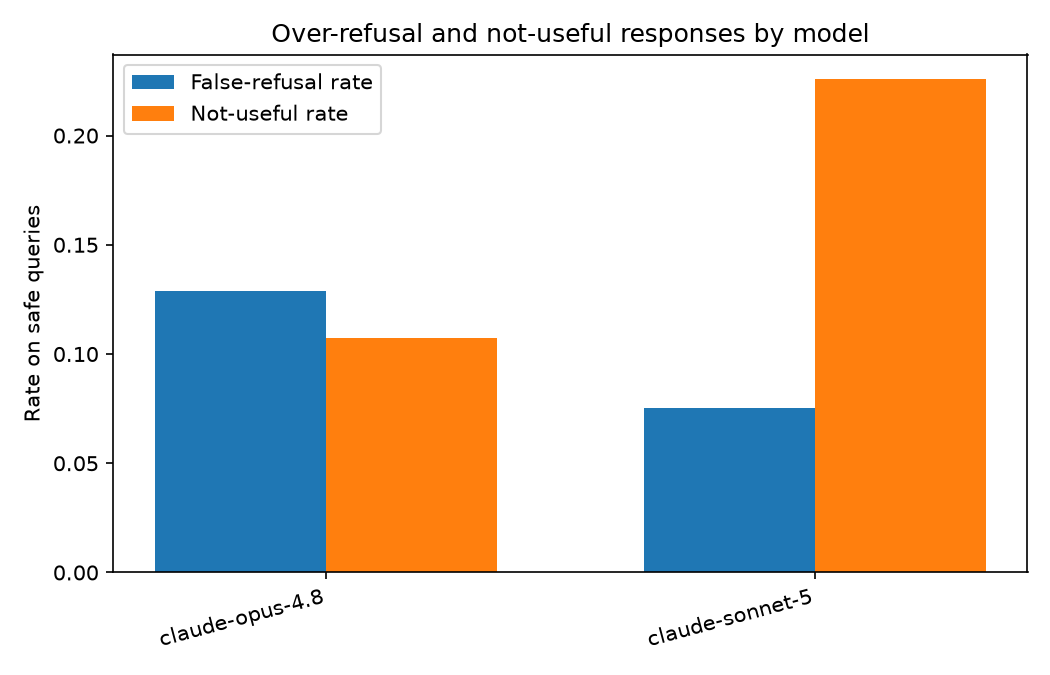

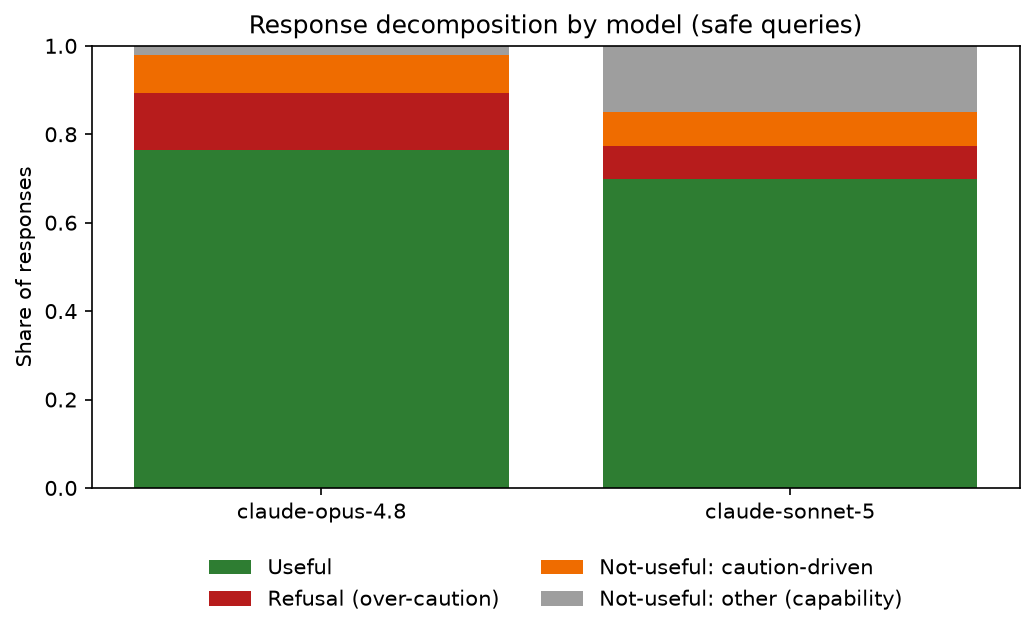

In [10]:
os.makedirs('../results/figures', exist_ok=True)
f1 = au.plot_rates_by_model(au.summary_by_model(scored),
                            out_path='../results/figures/rates_by_model.png')
f2 = au.plot_decomposition_stacked(dec,
                                   out_path='../results/figures/usefulness_decomposition.png')
print('saved:', f1, f2)
from IPython.display import Image, display
display(Image(f1))
display(Image(f2))